In [172]:
"""
Notes on AI:
I used github copilot for help with autocomplete and for creating nice looking graphs and charts
I also used generative AI to help me with things I was confused about, for example interpreting stastics and p-values
"""

'\nNotes on AI:\nI used github copilot for help with autocomplete and for creating nice looking graphs and charts\nI also used generative AI to help me with things I was confused about, for example interpreting stastics and p-values\n'

In [173]:
import numpy as np
import json
import matplotlib.pyplot as plt
import pandas as pd
import glob
from pathlib import Path
import umap
from sklearn.preprocessing import StandardScaler
from scipy import stats
from scipy.stats import entropy

In [174]:
color_map = {
    "boed": "blue",
    "dboed": "orange",
}
belief_combos = [
    ('boed', 'task_beliefs', 'BOED Task'),
    ('dboed', 'task_beliefs', 'DBOED Task'),
    ('dboed', 'design_beliefs', 'DBOED Design')
]

In [175]:
with open("llm-belief-embeddings/belief_index.json", "r") as f:
    belief_index = json.load(f)

with open("concept-graph-embeddings/concepts.json", "r") as f:
    concepts = json.load(f)

with open("concept-graph-embeddings/belief_signal_index.json", "r") as f:
    belief_signal_index = json.load(f)

In [176]:
embeddings = np.load("llm-belief-embeddings/belief_embeddings.npy")
belief_signals = np.load("concept-graph-embeddings/belief_signals.npy")
concept_embeddings = np.load("concept-graph-embeddings/concept_embeddings.npy")
print("Embeddings Shape:", embeddings.shape)
print("Concept Graph Data Loaded:")
print(f"-number of concepts: {len(concepts)}")
print(f"-belief signals shape: {belief_signals.shape}")
print(f"-concept embeddings shape: {concept_embeddings.shape}")
print(f"-belief signal index count: {len(belief_signal_index)}")


Embeddings Shape: (1332, 4096)
Concept Graph Data Loaded:
-number of concepts: 1000
-belief signals shape: (1332, 1000)
-concept embeddings shape: (1000, 4096)
-belief signal index count: 1332


In [177]:
def belief_embeddings_df(belief_index, embeddings):
    df = pd.DataFrame(belief_index)
    df["embedding"] = list(embeddings)
    return df


def episode_steps_df(base_path, folders=("boed", "dboed")):
    rows = []

    for folder in folders:
        for file in glob.glob(str(base_path / folder / "*.json")):
            with open(file, "r") as f:
                data = json.load(f)
            episode_id = data.get("episode_id")
            if episode_id is None:
                continue

            for step in data.get("step_metrics", []):
                rows.append(
                    {
                        "episode_id": episode_id,
                        "folder": folder,
                        "agent_type": data.get("agent_type"),
                        "total_steps": data.get("total_steps", 0),
                        "step_number": step.get("step"),
                        "task_belief_complexity": step.get("task_belief_complexity", 0),
                        "design_belief_complexity": step.get(
                            "design_belief_complexity", 0
                        ),
                        "prediction_confidence": step.get("prediction_confidence", 0),
                        "prediction_accuracy": step.get("prediction_accuracy"),
                        "reward": step.get("reward", 0),
                        "task_eig": step.get("task_eig", 0),
                        "design_eig": step.get("design_eig", 0),
                    }
                )

    return pd.DataFrame(rows)


df_concept_signals = pd.DataFrame(belief_signal_index)
df_concept_signals["concept_signal"] = list(belief_signals)

df_beliefs = belief_embeddings_df(belief_index, embeddings)
base_path = Path("gemini-exploration-traces/gemini-2.5-pro-validation-only_metrics")
df_steps = episode_steps_df(base_path)
df = df_beliefs.merge(df_steps, on=["episode_id", "folder", "step_number"], how="left")

df = df.merge(
    df_concept_signals[['belief_id', 'concept_signal']], 
    on='belief_id', 
    how='left'
)

print(f"\nMerged dataframe shape: {df.shape}")


Merged dataframe shape: (1332, 21)


In [178]:
df = df.sort_values(["episode_id", "folder", "step_number"])

episode_stats = (
    df.groupby(["episode_id", "folder"])
    .apply(
        lambda g: pd.Series({
            "total_task_complexity_change": g["task_belief_complexity"].diff().abs().sum(),
            "total_design_complexity_change": g["design_belief_complexity"].diff().abs().sum(),
            "avg_task_complexity_change": g["task_belief_complexity"].diff().abs().mean(),
            "avg_design_complexity_change": g["design_belief_complexity"].diff().abs().mean(),
            "max_task_complexity_change": g["task_belief_complexity"].diff().abs().max(),
            "max_design_complexity_change": g["design_belief_complexity"].diff().abs().max(),
            "episode_accuracy": g["prediction_accuracy"].dropna().iloc[-1] if g["prediction_accuracy"].dropna().shape[0] > 0 else None,
        })
    )
    .reset_index()
)

df = df.merge(episode_stats, on=["episode_id", "folder"], how="left")

/tmp/ipykernel_127200/913275119.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [179]:
df_unique = (
    df.sort_values(["episode_id", "folder", "step_number"])
      .groupby(["episode_id", "folder"], as_index=False)
      .last()
)

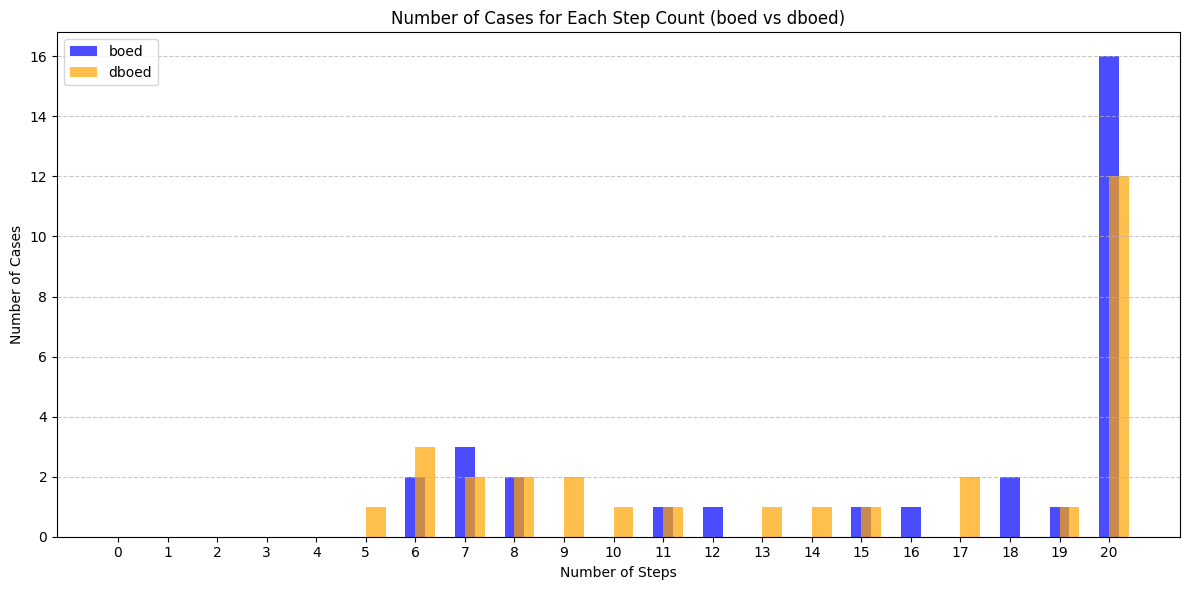

In [180]:
counts = df_unique.groupby(["folder", "total_steps"]).size().reset_index(name="n")
max_steps = int(df_unique["total_steps"].max()) if "total_steps" in df_unique.columns else 0
x_values = list(range(max_steps + 1))
boed = counts[counts.folder == "boed"].set_index("total_steps")["n"] if not counts[counts.folder == "boed"].empty else pd.Series(dtype=int)
dboed = counts[counts.folder == "dboed"].set_index("total_steps")["n"] if not counts[counts.folder == "dboed"].empty else pd.Series(dtype=int)
boed_y_values = [int(boed.get(s, 0)) for s in x_values]
dboed_y_values = [int(dboed.get(s, 0)) for s in x_values]

plt.figure(figsize=(12, 6))

plt.bar(
    x_values,
    boed_y_values,
    color=color_map["boed"],
    alpha=0.7,
    label="boed",
    width=0.4,
    align="center",
)
plt.bar(
    x_values,
    dboed_y_values,
    color=color_map["dboed"],
    alpha=0.7,
    label="dboed",
    width=0.4,
    align="edge",
)

plt.xlabel("Number of Steps")
plt.ylabel("Number of Cases")
plt.title("Number of Cases for Each Step Count (boed vs dboed)")
plt.xticks(range(0, max_steps + 1, 1))
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.legend()

plt.show()

In [181]:
for folder in df_unique["folder"].unique():
    folder_data = df_unique[df_unique["folder"] == folder]
    avg_accuracy = folder_data["episode_accuracy"].mean()
    print(f"{folder}: avergae acc = {avg_accuracy:.4f}")

boed: avergae acc = 0.6333
dboed: avergae acc = 0.7167


In [182]:
def compute_avg_belief_change(df):  
    df = df.sort_values(['episode_id', 'step_number'])
    max_step = int(df['step_number'].max())
    _belief_changes = []
    
    for step in range(1, max_step):
        curr_step = df[df['step_number'] == step][['episode_id', 'embedding']]
        next_step = df[df['step_number'] == step + 1][['episode_id', 'embedding']]

        pairs = curr_step.merge(next_step, on='episode_id', suffixes=('_curr', '_next'))
        changes = pairs.apply(
            lambda row: np.linalg.norm(row['embedding_curr'] - row['embedding_next']),
            axis=1
        )
        _belief_changes.append(changes.mean())
    
    return _belief_changes


In [183]:
belief_changes = {}
for folder, belief_type, label in belief_combos:
    belief_changes[label] = compute_avg_belief_change(
        df[(df["folder"] == folder) & (df["belief_type"] == belief_type)]
        [['episode_id', 'step_number', 'embedding']]
    )

belief_changes_by_outcome = {'Correct': {}, 'Incorrect': {}}

for folder, belief_type, label in belief_combos:
    belief_changes_by_outcome['Correct'][label] = compute_avg_belief_change(
        df[(df["folder"] == folder) & (df["belief_type"] == belief_type) & (df["episode_accuracy"] == 1.0)]
        [['episode_id', 'step_number', 'embedding']]
    )
    belief_changes_by_outcome['Incorrect'][label] = compute_avg_belief_change(
        df[(df["folder"] == folder) & (df["belief_type"] == belief_type) & (df["episode_accuracy"] == 0.0)]
        [['episode_id', 'step_number', 'embedding']]
    )

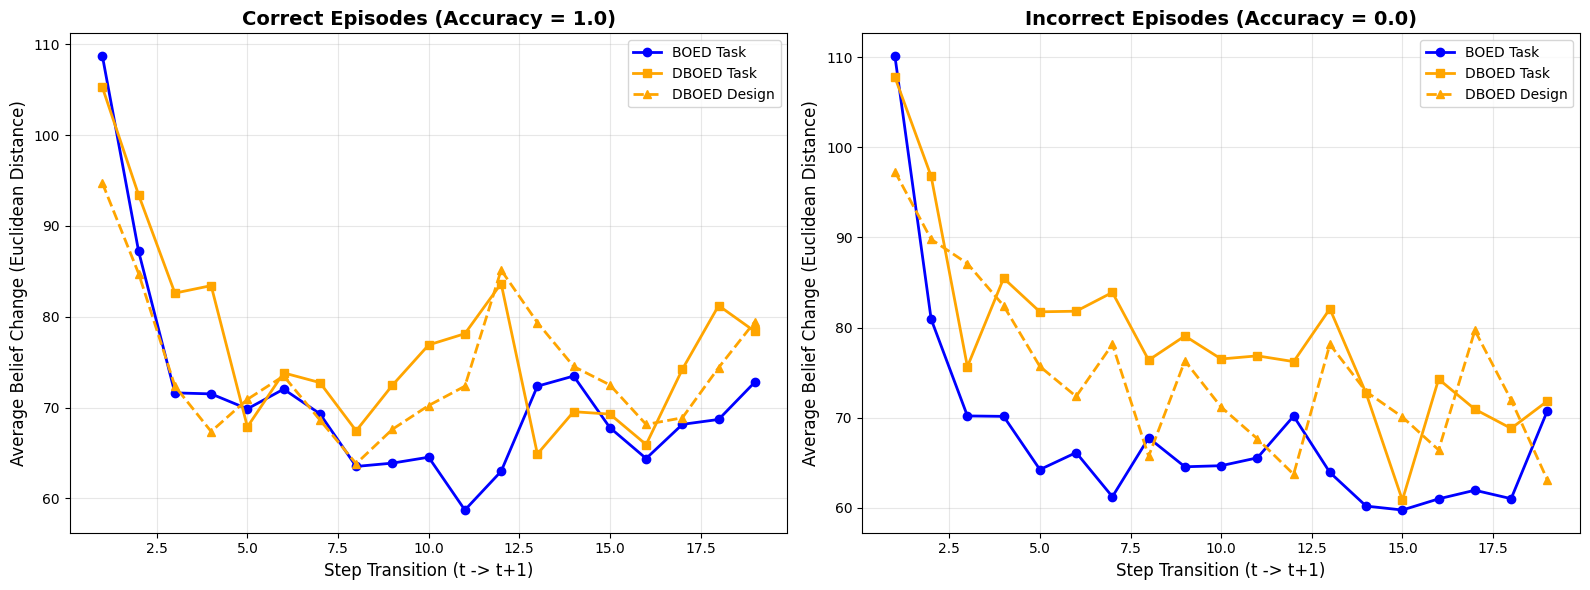

In [184]:


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

markers = ['o', 's', '^']
linestyles = ['-', '-', '--']

for i, (folder, belief_type, label) in enumerate(belief_combos):
    changes = belief_changes_by_outcome['Correct'][label]
    ax1.plot(range(1, len(changes) + 1), changes,
             label=label, color=color_map[folder], ls=linestyles[i], linewidth=2, marker=markers[i])

ax1.set_xlabel("Step Transition (t -> t+1)", fontsize=12)
ax1.set_ylabel("Average Belief Change (Euclidean Distance)", fontsize=12)
ax1.set_title("Correct Episodes (Accuracy = 1.0)", fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

for i, (folder, belief_type, label) in enumerate(belief_combos):
    changes = belief_changes_by_outcome['Incorrect'][label]
    ax2.plot(range(1, len(changes) + 1), changes,
             label=label, color=color_map[folder], ls=linestyles[i], linewidth=2, marker=markers[i])

ax2.set_xlabel("Step Transition (t -> t+1)", fontsize=12)
ax2.set_ylabel("Average Belief Change (Euclidean Distance)", fontsize=12)
ax2.set_title("Incorrect Episodes (Accuracy = 0.0)", fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

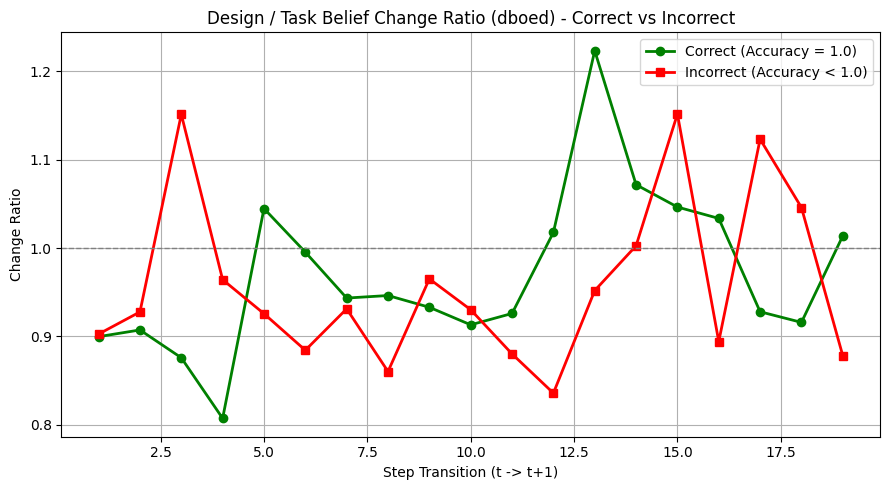

In [200]:
dboed_df = df[(df["folder"] == "dboed")]

def compute_change_ratio(task_changes, design_changes, min_threshold=1e-8):
    task_arr = np.array(task_changes)
    design_arr = np.array(design_changes)
    min_len = min(len(task_arr), len(design_arr))
    
    ratio = np.full(min_len, np.nan)
    valid = task_arr[:min_len] > min_threshold
    ratio[valid] = design_arr[:min_len][valid] / task_arr[:min_len][valid]
    return ratio

# Compute ratios for both outcomes
change_ratio_correct = compute_change_ratio(
    belief_changes_by_outcome['Correct']['DBOED Task'],
    belief_changes_by_outcome['Correct']['DBOED Design']
)
change_ratio_incorrect = compute_change_ratio(
    belief_changes_by_outcome['Incorrect']['DBOED Task'],
    belief_changes_by_outcome['Incorrect']['DBOED Design']
)

# Plot both lines
plt.figure(figsize=(9, 5))
plt.plot(
    range(1, len(change_ratio_correct) + 1),
    change_ratio_correct,
    color='green',
    marker="o",
    linewidth=2,
    label="Correct (Accuracy = 1.0)"
)
plt.plot(
    range(1, len(change_ratio_incorrect) + 1),
    change_ratio_incorrect,
    color='red',
    marker="s",
    linewidth=2,
    label="Incorrect (Accuracy < 1.0)"
)

plt.axhline(1.0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Step Transition (t -> t+1)")
plt.ylabel("Change Ratio")
plt.title("Design / Task Belief Change Ratio (dboed) - Correct vs Incorrect")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

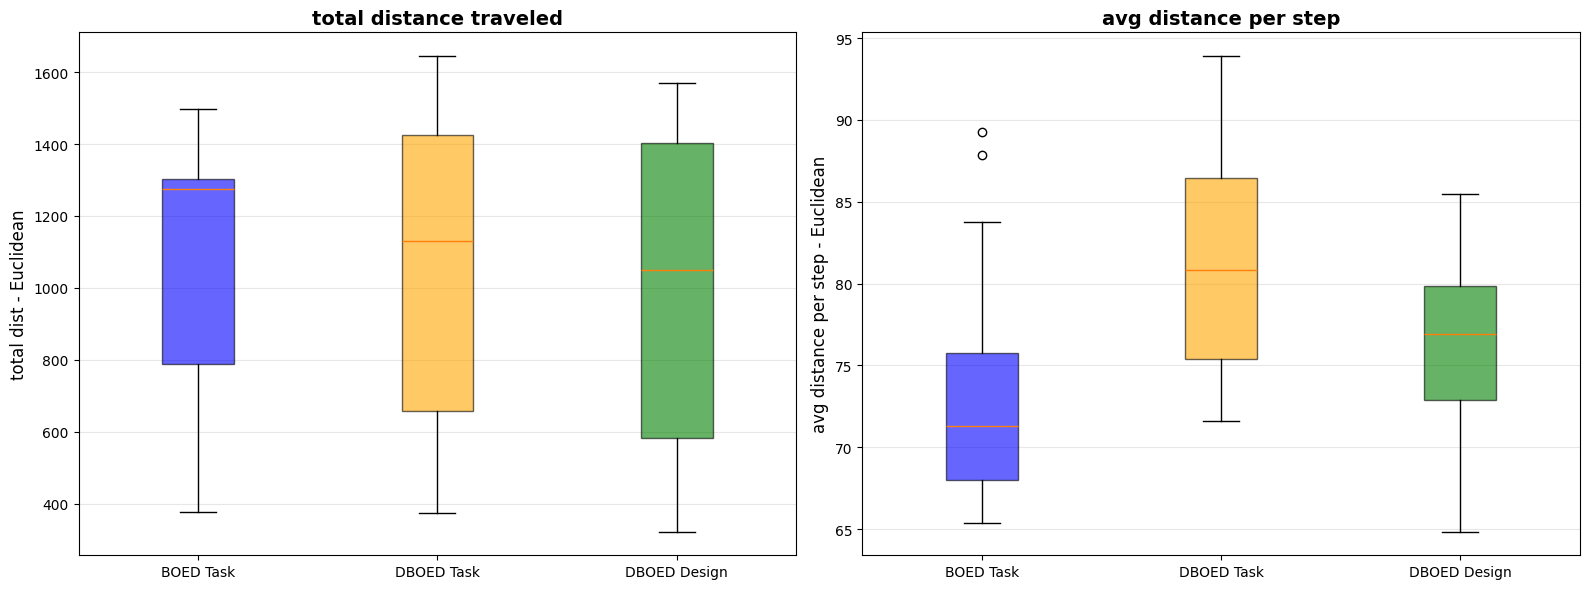

In [186]:
def compute_total_distance_per_agent(df):
    def calc_distance(group):
        embeddings = np.vstack(group.sort_values('step_number')['embedding'].values)
        
        if len(embeddings) <= 1:
            return pd.Series({'total_distance': 0, 'avg_distance_per_step': 0, 'n_steps': len(embeddings)})
        
        distances = np.linalg.norm(embeddings[1:] - embeddings[:-1], axis=1)
        total = distances.sum()
        return pd.Series({'total_distance': total, 'avg_distance_per_step': total / len(distances), 'n_steps': len(embeddings)})
    
    return df.groupby(['episode_id', 'folder', 'belief_type']).apply(calc_distance, include_groups=False).reset_index()

distance_df_euclidean = compute_total_distance_per_agent(df)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
data_to_plot = [
    distance_df_euclidean[(distance_df_euclidean['folder'] == folder) & 
                         (distance_df_euclidean['belief_type'] == belief_type)]['total_distance'].values
    for folder, belief_type, label in belief_combos
]
bp = ax.boxplot(data_to_plot, tick_labels=[label for _, _, label in belief_combos], patch_artist=True)
for patch, color in zip(bp['boxes'], ['blue', 'orange', 'green']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('total dist - Euclidean', fontsize=12)
ax.set_title('total distance traveled', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
data_to_plot = [
    distance_df_euclidean[(distance_df_euclidean['folder'] == folder) & 
                         (distance_df_euclidean['belief_type'] == belief_type)]['avg_distance_per_step'].values
    for folder, belief_type, label in belief_combos
]
bp = ax.boxplot(data_to_plot, tick_labels=[label for _, _, label in belief_combos], patch_artist=True)
for patch, color in zip(bp['boxes'], ['blue', 'orange', 'green']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('avg distance per step - Euclidean', fontsize=12)
ax.set_title('avg distance per step', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


In [187]:
def total_embedding_change_per_episode(df, normalize=False):
    df = df.sort_values(["episode_id", "folder", "belief_type", "step_number"])
    
    episode_totals = (
        df.groupby(["episode_id", "folder", "belief_type"])
          .apply(
              lambda g: pd.Series({
                  "total_change": np.sum([
                      np.linalg.norm(g.iloc[i+1]["embedding"] - g.iloc[i]["embedding"])
                      for i in range(len(g) - 1)
                  ]) if len(g) > 1 else 0,
                  "num_steps": len(g),
                  "accuracy": g.iloc[0]["episode_accuracy"] if len(g) > 0 else 0
              })
          )
          .reset_index()
    )
    
    episode_totals["outcome"] = episode_totals["accuracy"].apply(
        lambda x: "Correct" if x == 1.0 else "Incorrect"
    )
    
    episode_totals["group"] = (
        episode_totals["folder"].str.upper() + " - " + 
        episode_totals["belief_type"].str.replace("_beliefs", "").str.title() + " - " +
        episode_totals["outcome"]
    )
    
    if normalize:
        episode_totals["total_change"] = episode_totals["total_change"] / episode_totals["num_steps"]
    
    return episode_totals

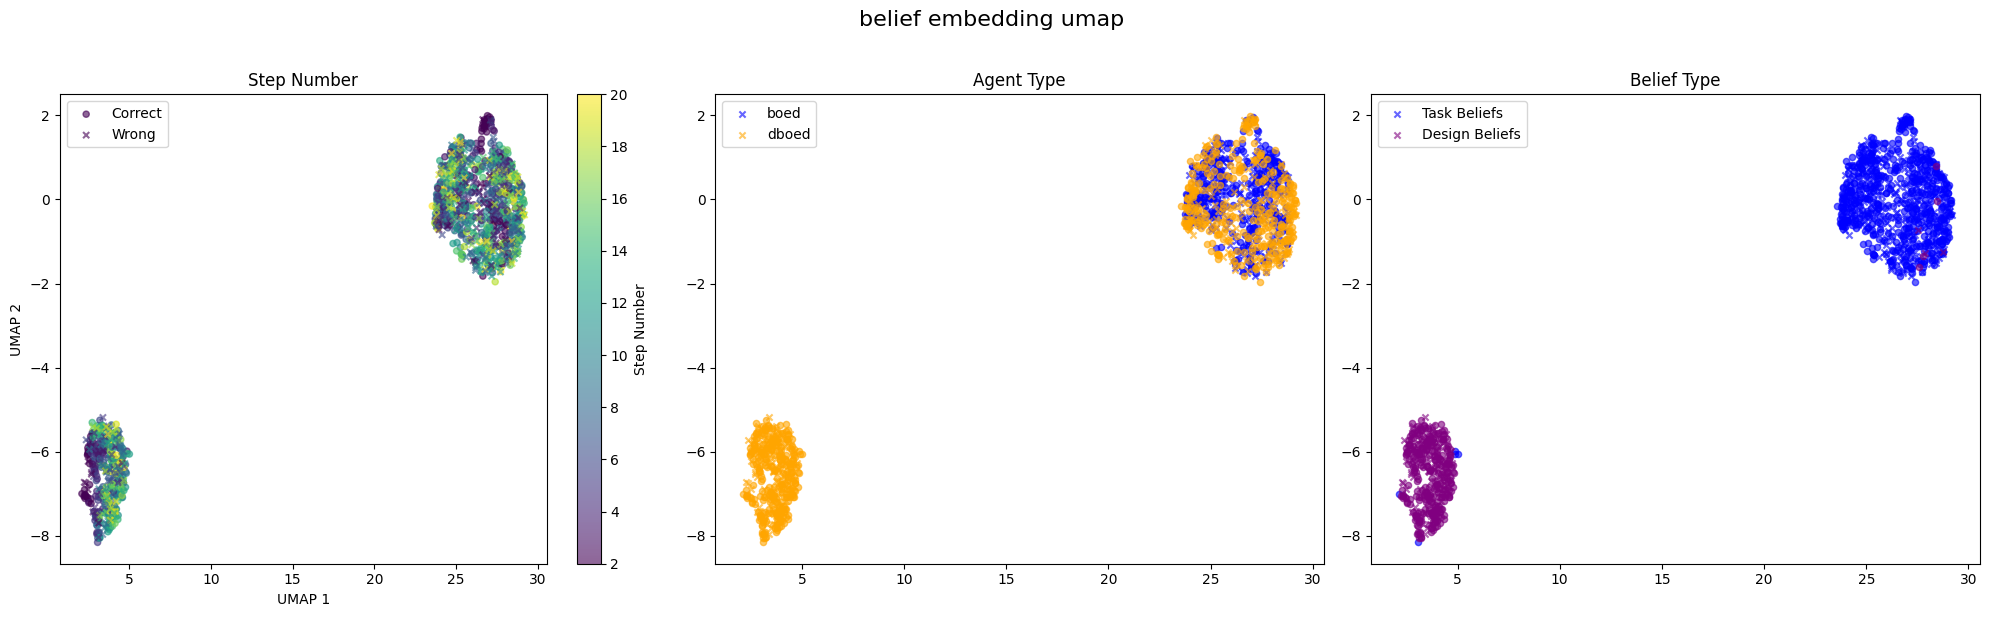

In [188]:
df_filtered = df[df['step_number'] > 1].copy()

embeddings_array = np.vstack(df_filtered['embedding'].values)

scaler = StandardScaler()
scaled_embeddings = scaler.fit_transform(embeddings_array)

umap_model = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1, n_jobs=1)
embedding_2d = umap_model.fit_transform(scaled_embeddings)

df_viz = df_filtered.copy()
df_viz['UMAP1'] = embedding_2d[:, 0]
df_viz['UMAP2'] = embedding_2d[:, 1]

belief_type_colors = {
    'task_beliefs': 'blue',
    'design_beliefs': 'purple'
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

correct = df_viz['episode_accuracy'] == 1.0
axes[0].scatter(df_viz.loc[correct, 'UMAP1'], df_viz.loc[correct, 'UMAP2'], 
               c=df_viz.loc[correct, 'step_number'], cmap='viridis', alpha=0.6, s=20, marker='o', label='Correct')
scatter_wrong = axes[0].scatter(df_viz.loc[~correct, 'UMAP1'], df_viz.loc[~correct, 'UMAP2'], 
                               c=df_viz.loc[~correct, 'step_number'], cmap='viridis', alpha=0.6, s=20, marker='x', label='Wrong')
fig.colorbar(scatter_wrong, ax=axes[0], label='Step Number')
axes[0].set_xlabel('UMAP 1')
axes[0].set_ylabel('UMAP 2')
axes[0].set_title('Step Number')
axes[0].legend()

for folder in df_viz['folder'].unique():
    folder_mask = df_viz['folder'] == folder
    correct_mask = folder_mask & correct
    wrong_mask = folder_mask & ~correct
    axes[1].scatter(df_viz.loc[correct_mask, 'UMAP1'], df_viz.loc[correct_mask, 'UMAP2'], 
                   alpha=0.6, s=20, color=color_map.get(folder), marker='o')
    axes[1].scatter(df_viz.loc[wrong_mask, 'UMAP1'], df_viz.loc[wrong_mask, 'UMAP2'], 
                   label=folder if wrong_mask.sum() > 0 else None, alpha=0.6, s=20, color=color_map.get(folder), marker='x')
axes[1].set_title('Agent Type')
axes[1].legend()

for belief_type in df_viz['belief_type'].unique():
    belief_mask = df_viz['belief_type'] == belief_type
    correct_mask = belief_mask & correct
    wrong_mask = belief_mask & ~correct
    color = belief_type_colors.get(belief_type, 'gray')
    axes[2].scatter(df_viz.loc[correct_mask, 'UMAP1'], df_viz.loc[correct_mask, 'UMAP2'], 
                   alpha=0.6, s=20, color=color, marker='o')
    axes[2].scatter(df_viz.loc[wrong_mask, 'UMAP1'], df_viz.loc[wrong_mask, 'UMAP2'], 
                   label=belief_type.replace('_', ' ').title() if wrong_mask.sum() > 0 else None, 
                   alpha=0.6, s=20, color=color, marker='x')
axes[2].set_title('Belief Type')
axes[2].legend()

plt.suptitle('belief embedding umap ', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

It is interesting that therere some task beliefs in the clump of design beliefs and there are some design beliefs in teh clumb of task beliefs, this could indicate that the model is naturally recognizing that it needs both belief structures to function

In [189]:
episode_accuracy_by_agent = df.groupby(['episode_id', 'folder'])['episode_accuracy'].first().reset_index()

episode_comparison = episode_accuracy_by_agent.pivot(index='episode_id', columns='folder', values='episode_accuracy')

disagreements = episode_comparison[
    ((episode_comparison['boed'] == 1.0) & (episode_comparison['dboed'] == 0.0)) |
    ((episode_comparison['boed'] == 0.0) & (episode_comparison['dboed'] == 1.0))
]

disagreement_episode_ids = disagreements.index.tolist()
mistakes = df[df['episode_id'].isin(disagreement_episode_ids)]



2 disagreeing episodes


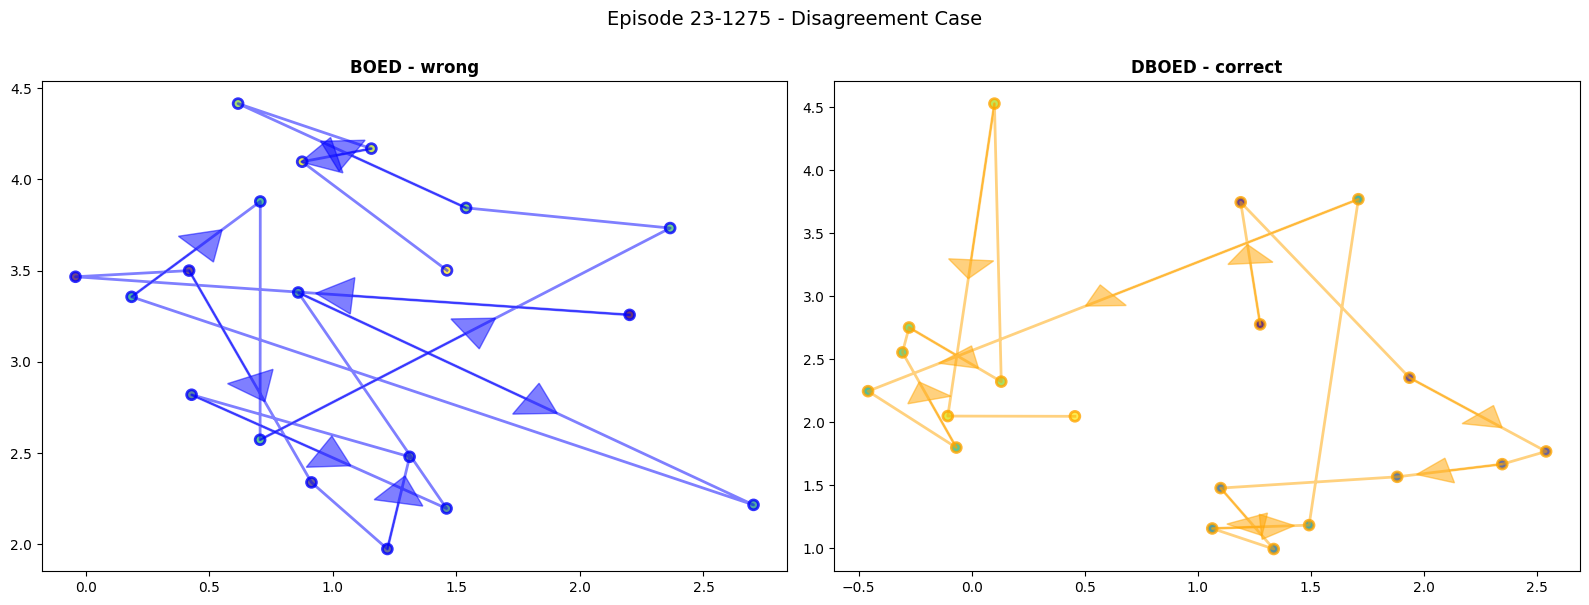

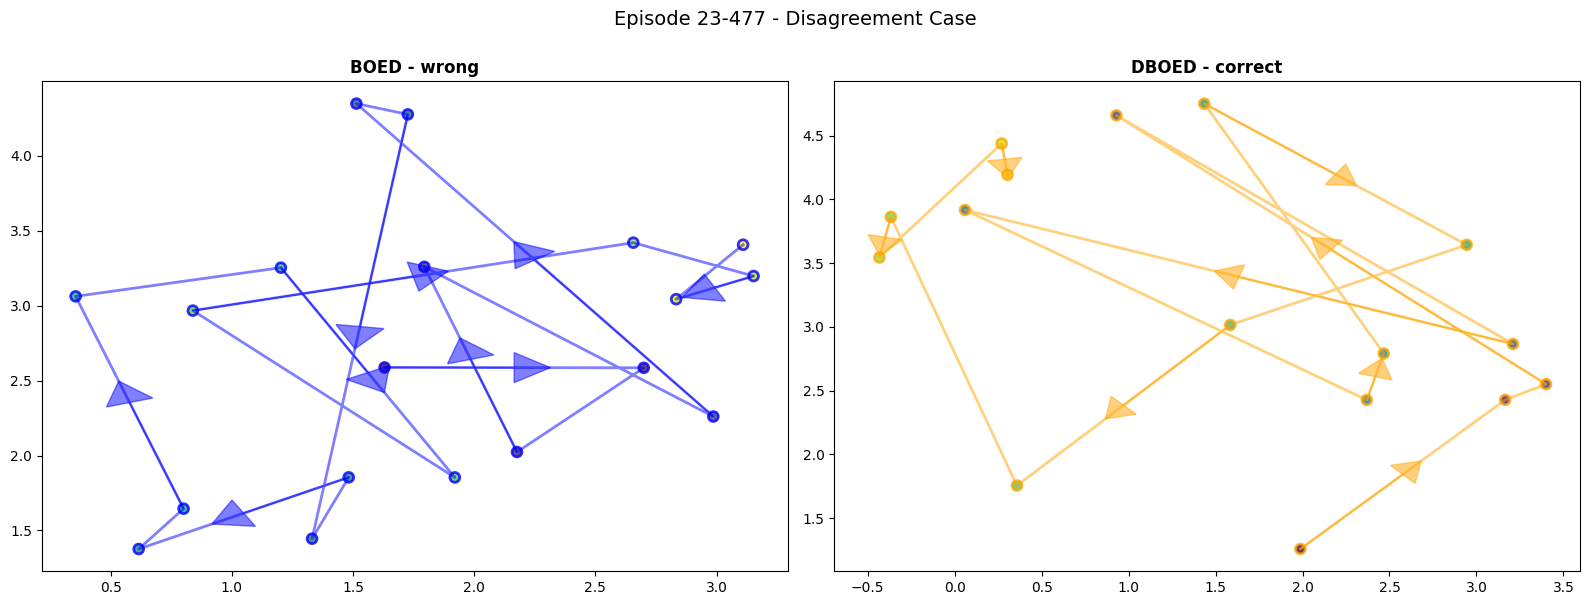

In [190]:
print(f"{len(disagreement_episode_ids)} disagreeing episodes")

mistakes_traj = mistakes[(mistakes['belief_type'] == 'task_beliefs') & (mistakes['step_number'] > 1)]


embeddings_array = np.vstack(mistakes_traj['embedding'].values)
scaler = StandardScaler()
scaled_embeddings = scaler.fit_transform(embeddings_array)

umap_model = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1, n_jobs=1)
embedding_2d = umap_model.fit_transform(scaled_embeddings)

mistakes_viz = mistakes_traj.copy()
mistakes_viz['UMAP1'] = embedding_2d[:, 0]
mistakes_viz['UMAP2'] = embedding_2d[:, 1]

for episode_id in disagreement_episode_ids[:5]:  
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    episode_data = mistakes_viz[mistakes_viz['episode_id'] == episode_id]
    
    if len(episode_data) == 0:
        continue
    
    
    boed_data = episode_data[episode_data['folder'] == 'boed'].sort_values('step_number')
    if len(boed_data) >= 2:
        boed_correct = boed_data['episode_accuracy'].iloc[0] == 1.0
        
        axes[0].plot(boed_data['UMAP1'], boed_data['UMAP2'], 
                    color=color_map['boed'], alpha=0.5, linewidth=2)
        axes[0].scatter(boed_data['UMAP1'], boed_data['UMAP2'],
                       c=boed_data['step_number'], cmap='viridis',
                       s=50, alpha=0.8, edgecolors=color_map['boed'], linewidths=2)
        
        # Add arrows
        for i in range(0, len(boed_data) - 1, 2):
            dx = boed_data.iloc[i+1]['UMAP1'] - boed_data.iloc[i]['UMAP1']
            dy = boed_data.iloc[i+1]['UMAP2'] - boed_data.iloc[i]['UMAP2']
            axes[0].arrow(boed_data.iloc[i]['UMAP1'], boed_data.iloc[i]['UMAP2'],
                         dx*0.5, dy*0.5, head_width=0.2, head_length=0.15,
                         fc=color_map['boed'], ec=color_map['boed'], alpha=0.5, linewidth=1)
        
        result = "correct" if boed_correct else "wrong"
        axes[0].set_title(f'BOED - {result}', fontsize=12, fontweight='bold')
    else:
        axes[0].set_title('BOED - No trajectory data', fontsize=12)
    
    # Plot DBOED trajectory (right)
    dboed_data = episode_data[episode_data['folder'] == 'dboed'].sort_values('step_number')
    if len(dboed_data) >= 2:
        dboed_correct = dboed_data['episode_accuracy'].iloc[0] == 1.0
        
        axes[1].plot(dboed_data['UMAP1'], dboed_data['UMAP2'],
                    color=color_map['dboed'], alpha=0.5, linewidth=2)
        scatter = axes[1].scatter(dboed_data['UMAP1'], dboed_data['UMAP2'],
                                 c=dboed_data['step_number'], cmap='viridis',
                                 s=50, alpha=0.8, edgecolors=color_map['dboed'], linewidths=2)
        
        # Add arrows
        for i in range(0, len(dboed_data) - 1, 2):
            dx = dboed_data.iloc[i+1]['UMAP1'] - dboed_data.iloc[i]['UMAP1']
            dy = dboed_data.iloc[i+1]['UMAP2'] - dboed_data.iloc[i]['UMAP2']
            axes[1].arrow(dboed_data.iloc[i]['UMAP1'], dboed_data.iloc[i]['UMAP2'],
                         dx*0.5, dy*0.5, head_width=0.2, head_length=0.15,
                         fc=color_map['dboed'], ec=color_map['dboed'], alpha=0.5, linewidth=1)
        
        result = "correct" if dboed_correct else "wrong"
        axes[1].set_title(f'DBOED - {result}', fontsize=12, fontweight='bold')
    else:
        axes[1].set_title('DBOED - No trajectory data', fontsize=12)
    
    plt.suptitle(f'Episode {episode_id} - Disagreement Case', fontsize=14, y=1.00)
    plt.tight_layout()
    plt.show()

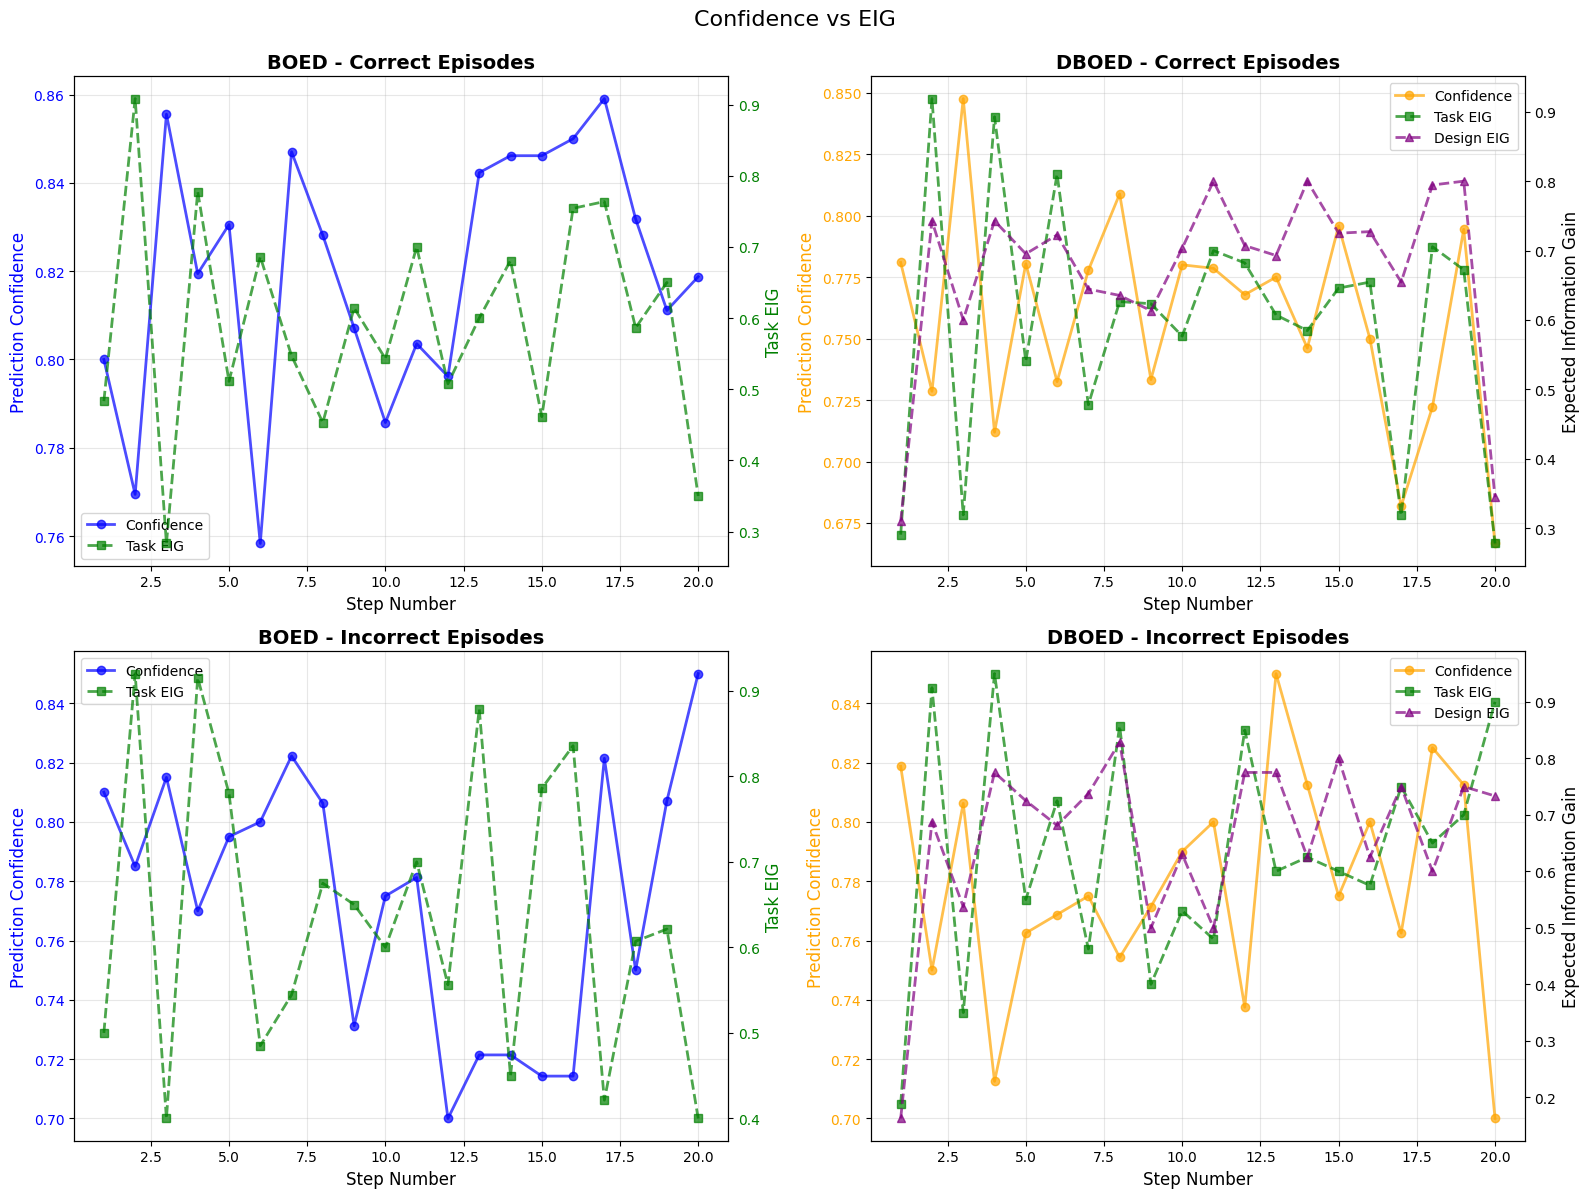

In [191]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

step_metrics = df.groupby(['folder', 'episode_accuracy', 'step_number']).agg({
    'prediction_confidence': 'mean',
    'task_eig': 'mean',
    'design_eig': 'mean'
}).reset_index()

boed_correct = step_metrics[(step_metrics['folder'] == 'boed') & 
                            (step_metrics['episode_accuracy'] == 1.0)].sort_values('step_number')

ax1 = axes[0, 0]
ax1_twin = ax1.twinx()
line1 = ax1.plot(boed_correct['step_number'], boed_correct['prediction_confidence'],
                 color=color_map['boed'], linewidth=2, marker='o', label='Confidence', alpha=0.7)
line2 = ax1_twin.plot(boed_correct['step_number'], boed_correct['task_eig'],
                      color='green', linewidth=2, marker='s', linestyle='--', label='Task EIG', alpha=0.7)

ax1.set_xlabel('Step Number', fontsize=12)
ax1.set_ylabel('Prediction Confidence', fontsize=12, color=color_map['boed'])
ax1_twin.set_ylabel('Task EIG', fontsize=12, color='green')
ax1.set_title('BOED - Correct Episodes', fontsize=14, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_map['boed'])
ax1_twin.tick_params(axis='y', labelcolor='green')
ax1.grid(True, alpha=0.3)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='best')

dboed_correct = step_metrics[(step_metrics['folder'] == 'dboed') & 
                             (step_metrics['episode_accuracy'] == 1.0)].sort_values('step_number')

ax2 = axes[0, 1]
ax2_twin = ax2.twinx()
line1 = ax2.plot(dboed_correct['step_number'], dboed_correct['prediction_confidence'],
                 color=color_map['dboed'], linewidth=2, marker='o', label='Confidence', alpha=0.7)
line2 = ax2_twin.plot(dboed_correct['step_number'], dboed_correct['task_eig'],
                      color='green', linewidth=2, marker='s', linestyle='--', label='Task EIG', alpha=0.7)
line3 = ax2_twin.plot(dboed_correct['step_number'], dboed_correct['design_eig'],
                      color='purple', linewidth=2, marker='^', linestyle='--', label='Design EIG', alpha=0.7)

ax2.set_xlabel('Step Number', fontsize=12)
ax2.set_ylabel('Prediction Confidence', fontsize=12, color=color_map['dboed'])
ax2_twin.set_ylabel('Expected Information Gain', fontsize=12)
ax2.set_title('DBOED - Correct Episodes', fontsize=14, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_map['dboed'])
ax2.grid(True, alpha=0.3)

lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc='best')

boed_incorrect = step_metrics[(step_metrics['folder'] == 'boed') & 
                              (step_metrics['episode_accuracy'] == 0.0)].sort_values('step_number')

ax3 = axes[1, 0]
ax3_twin = ax3.twinx()
line1 = ax3.plot(boed_incorrect['step_number'], boed_incorrect['prediction_confidence'],
                 color=color_map['boed'], linewidth=2, marker='o', label='Confidence', alpha=0.7)
line2 = ax3_twin.plot(boed_incorrect['step_number'], boed_incorrect['task_eig'],
                      color='green', linewidth=2, marker='s', linestyle='--', label='Task EIG', alpha=0.7)

ax3.set_xlabel('Step Number', fontsize=12)
ax3.set_ylabel('Prediction Confidence', fontsize=12, color=color_map['boed'])
ax3_twin.set_ylabel('Task EIG', fontsize=12, color='green')
ax3.set_title('BOED - Incorrect Episodes', fontsize=14, fontweight='bold')
ax3.tick_params(axis='y', labelcolor=color_map['boed'])
ax3_twin.tick_params(axis='y', labelcolor='green')
ax3.grid(True, alpha=0.3)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax3.legend(lines, labels, loc='best')

# Right: DBOED Incorrect
dboed_incorrect = step_metrics[(step_metrics['folder'] == 'dboed') & 
                               (step_metrics['episode_accuracy'] == 0.0)].sort_values('step_number')

ax4 = axes[1, 1]
ax4_twin = ax4.twinx()
line1 = ax4.plot(dboed_incorrect['step_number'], dboed_incorrect['prediction_confidence'],
                 color=color_map['dboed'], linewidth=2, marker='o', label='Confidence', alpha=0.7)
line2 = ax4_twin.plot(dboed_incorrect['step_number'], dboed_incorrect['task_eig'],
                      color='green', linewidth=2, marker='s', linestyle='--', label='Task EIG', alpha=0.7)
line3 = ax4_twin.plot(dboed_incorrect['step_number'], dboed_incorrect['design_eig'],
                      color='purple', linewidth=2, marker='^', linestyle='--', label='Design EIG', alpha=0.7)

ax4.set_xlabel('Step Number', fontsize=12)
ax4.set_ylabel('Prediction Confidence', fontsize=12, color=color_map['dboed'])
ax4_twin.set_ylabel('Expected Information Gain', fontsize=12)
ax4.set_title('DBOED - Incorrect Episodes', fontsize=14, fontweight='bold')
ax4.tick_params(axis='y', labelcolor=color_map['dboed'])
ax4.grid(True, alpha=0.3)

lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax4.legend(lines, labels, loc='best')

plt.suptitle('Confidence vs EIG', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()


when you think you have a lot to gain your confidence is low which makes sense because you know you can learn a lot more than might change the final outcome

In [192]:
df['concept_signal_normalized'] = df['concept_signal'].apply(
    lambda g: g / g.sum() if isinstance(g, np.ndarray) and g.sum() > 0 else (
        np.zeros_like(g) if isinstance(g, np.ndarray) else g
    )
)

df['concept_entropy'] = df['concept_signal_normalized'].apply(
    lambda g: -np.sum(g * np.log(g + 1e-12))
)

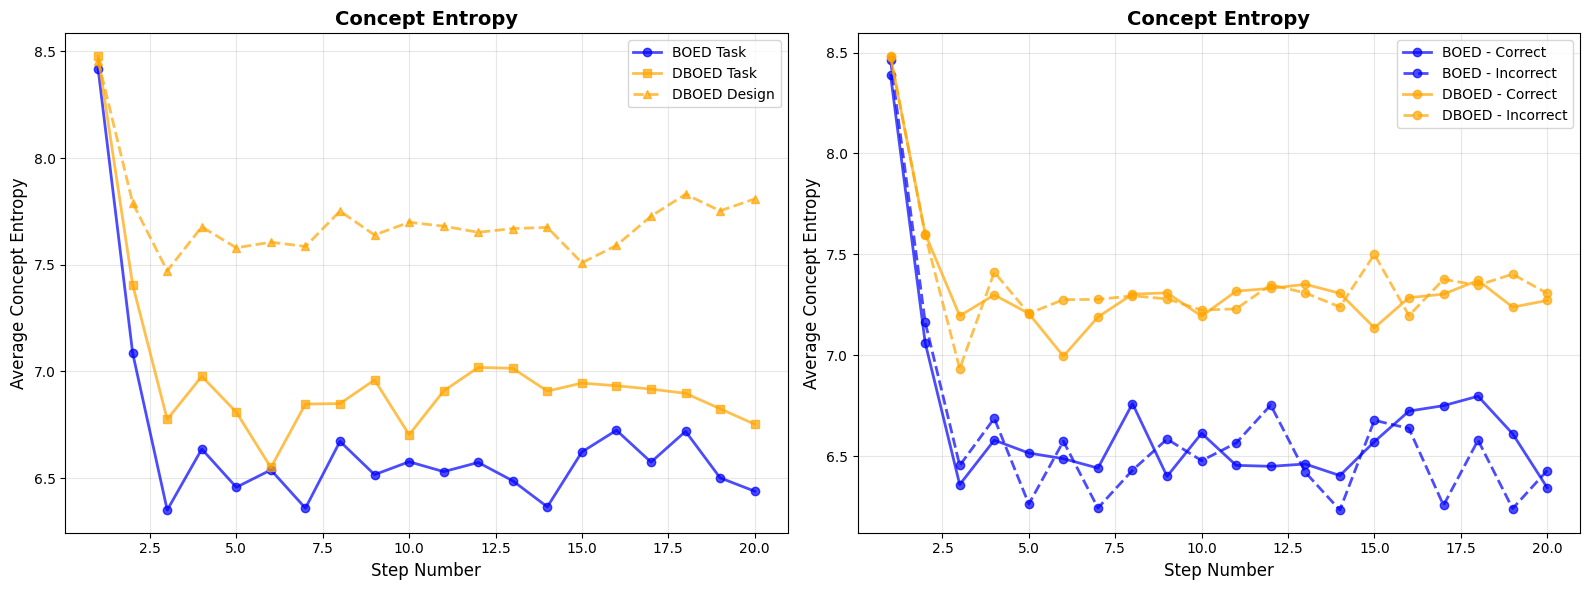

In [193]:
def compute_concept_entropy(signal):
    """Compute Shannon entropy of concept signal"""
    if not isinstance(signal, np.ndarray) or signal.sum() == 0:
        return np.nan
    p = signal / signal.sum() if signal.sum() > 0 else signal
    
    p_nonzero = p[p > 0]
    return entropy(p_nonzero, base=2)  

df['concept_entropy'] = df['concept_signal'].apply(compute_concept_entropy)

entropy_by_step = df.groupby(['folder', 'episode_accuracy', 'step_number'])['concept_entropy'].mean().reset_index()
entropy_by_agent_and_belief = df.groupby(['folder', 'belief_type', 'step_number'])['concept_entropy'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

markers = ['o', 's', '^']
linestyles = ['-', '-', '--']
for i, (folder, belief_type, label) in enumerate(belief_combos):
    subset = entropy_by_agent_and_belief[(entropy_by_agent_and_belief['folder'] == folder) & 
                                          (entropy_by_agent_and_belief['belief_type'] == belief_type)]
    axes[0].plot(subset['step_number'], subset['concept_entropy'],
                 marker=markers[i], linewidth=2, color=color_map[folder], 
                 linestyle=linestyles[i], label=label, alpha=0.7)

axes[0].set_xlabel('Step Number', fontsize=12)
axes[0].set_ylabel('Average Concept Entropy', fontsize=12)
axes[0].set_title('Concept Entropy', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: By outcome
for folder in ['boed', 'dboed']:
    for accuracy in [1.0, 0.0]:
        subset = entropy_by_step[(entropy_by_step['folder'] == folder) & 
                                (entropy_by_step['episode_accuracy'] == accuracy)]
        if len(subset) == 0:
            continue
        
        outcome = 'Correct' if accuracy == 1.0 else 'Incorrect'
        linestyle = '-' if accuracy == 1.0 else '--'
        label = f'{folder.upper()} - {outcome}'
        
        axes[1].plot(subset['step_number'], subset['concept_entropy'],
                    marker='o', linewidth=2, color=color_map[folder],
                    linestyle=linestyle, label=label, alpha=0.7)

axes[1].set_xlabel('Step Number', fontsize=12)
axes[1].set_ylabel('Average Concept Entropy', fontsize=12)
axes[1].set_title('Concept Entropy', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

it clearly with the design beliefs focuses on broader concpets which makes more sense?
the design beliefs encourage wider thinking

Analyzing shared episode: 24-320



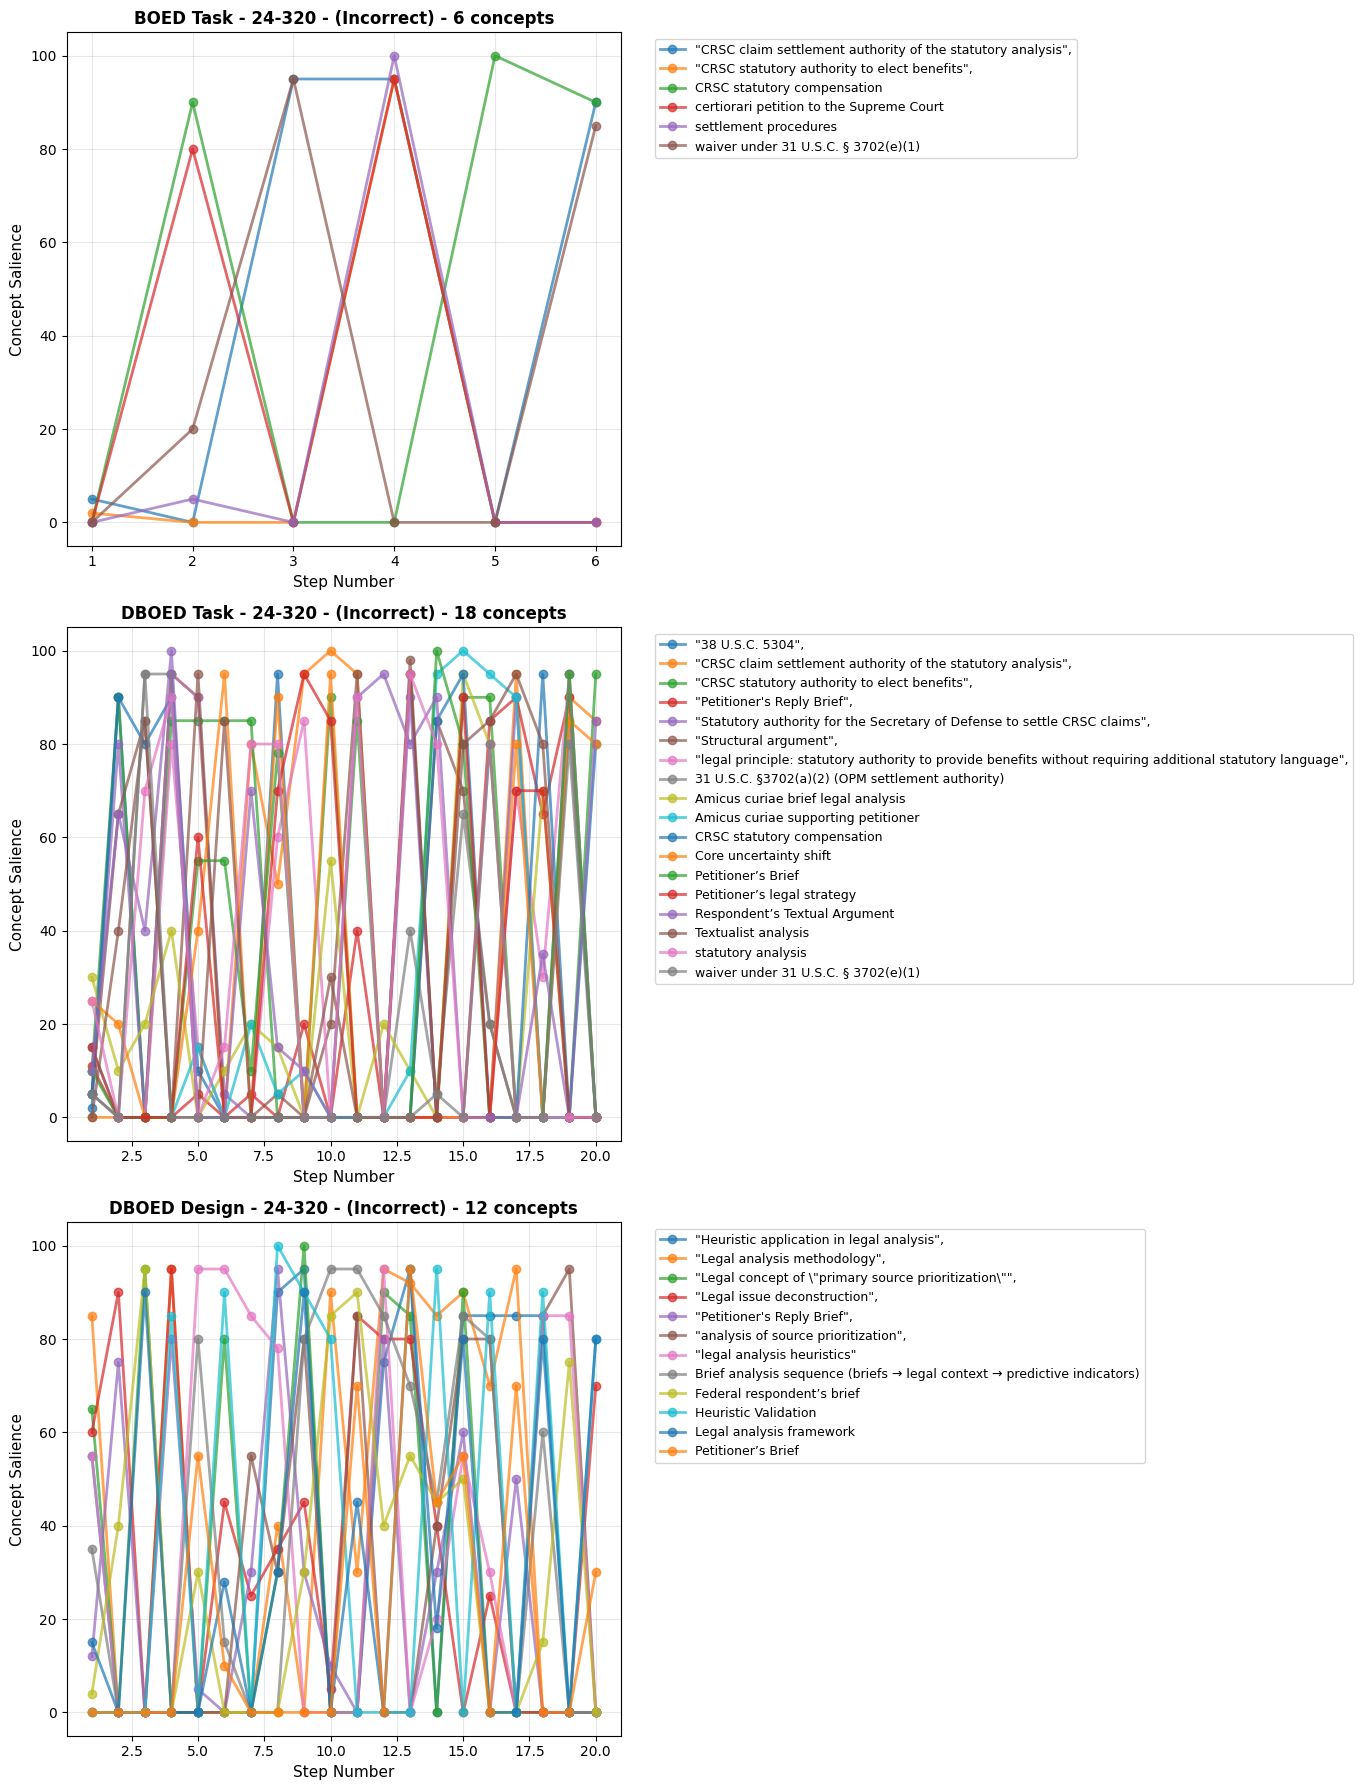

In [194]:
np.random.seed(99999)

minimum_concept_signal = 94.9

boed_episodes = df[(df['folder'] == 'boed') & (df['belief_type'] == 'task_beliefs')].groupby('episode_id').size()
dboed_episodes = df[(df['folder'] == 'dboed') & (df['belief_type'] == 'task_beliefs')].groupby('episode_id').size()

common_episodes = set(boed_episodes[boed_episodes > 2].index) & set(dboed_episodes[dboed_episodes > 2].index)
common_episodes = list(common_episodes)

shared_episode = np.random.choice(common_episodes) if common_episodes else None
print(f"Analyzing shared episode: {shared_episode}\n")

boed_episode = shared_episode
dboed_task_episode = shared_episode
dboed_design_episode = shared_episode

fig, axes = plt.subplots(3, 1, figsize=(14, 18))

episodes_info = [
    (shared_episode, folder, belief_type, label, i)
    for i, (folder, belief_type, label) in enumerate(belief_combos)
]

for episode_id, folder, belief_type, title, ax_idx in episodes_info:
    episode_data = df[(df['episode_id'] == episode_id) & 
                     (df['folder'] == folder) & 
                     (df['belief_type'] == belief_type)].sort_values('step_number')
    
    steps = episode_data['step_number'].values
    concept_signals_over_time = np.vstack(episode_data['concept_signal'].values)
    
    max_salience_per_concept = concept_signals_over_time.max(axis=0)
    high_salience_concepts = np.where(max_salience_per_concept > minimum_concept_signal)[0]
    
    for concept_idx in high_salience_concepts:
        concept_name = concepts[concept_idx] if concept_idx < len(concepts) else f"Concept_{concept_idx}"
        saliences = concept_signals_over_time[:, concept_idx]
        axes[ax_idx].plot(steps, saliences, marker='o', linewidth=2, alpha=0.7, label=concept_name)
    
    outcome = 'Correct' if episode_data.iloc[0]['episode_accuracy'] == 1.0 else 'Incorrect'
    axes[ax_idx].set_xlabel('Step Number', fontsize=11)
    axes[ax_idx].set_ylabel('Concept Salience', fontsize=11)
    axes[ax_idx].set_title(f'{title} - {episode_id} - ({outcome}) - {len(high_salience_concepts)} concepts', 
                          fontsize=12, fontweight='bold')
    axes[ax_idx].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    axes[ax_idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


with random seed 42 the deisgn belief covers very few topics which makes sense because its a high level of what the thing should be doing interestingly the task for dboed explores a ton of topics more than boed thinks about boed is more focused

that seems like an outlier tho usually the boed explores more tasks


Concept Breadth Analysis (threshold = 0.02)
 Belief Type     Mean ± SD Median     Range  N Episodes
   BOED Task 86.93 ± 40.97     77 [11, 155]          30
  DBOED Task 52.20 ± 27.35     49 [13, 121]          30
DBOED Design 16.37 ± 13.73     13   [0, 51]          30

Statistical Comparisons (t-tests):
                Comparison t-statistic  p-value Difference Significant (a=0.05)
   BOED Task vs DBOED Task       3.862 0.000286     +34.73                  YES
DBOED Task vs DBOED Design       6.414 0.000000     +35.83                  YES
 BOED Task vs DBOED Design       8.945 0.000000     +70.57                  YES


/tmp/ipykernel_127200/2002501023.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(['episode_id', 'folder', 'belief_type']).apply(process_group).reset_index()
/tmp/ipykernel_127200/2002501023.py:84: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_to_plot, labels=labels, patch_artist=True, widths=0.6)


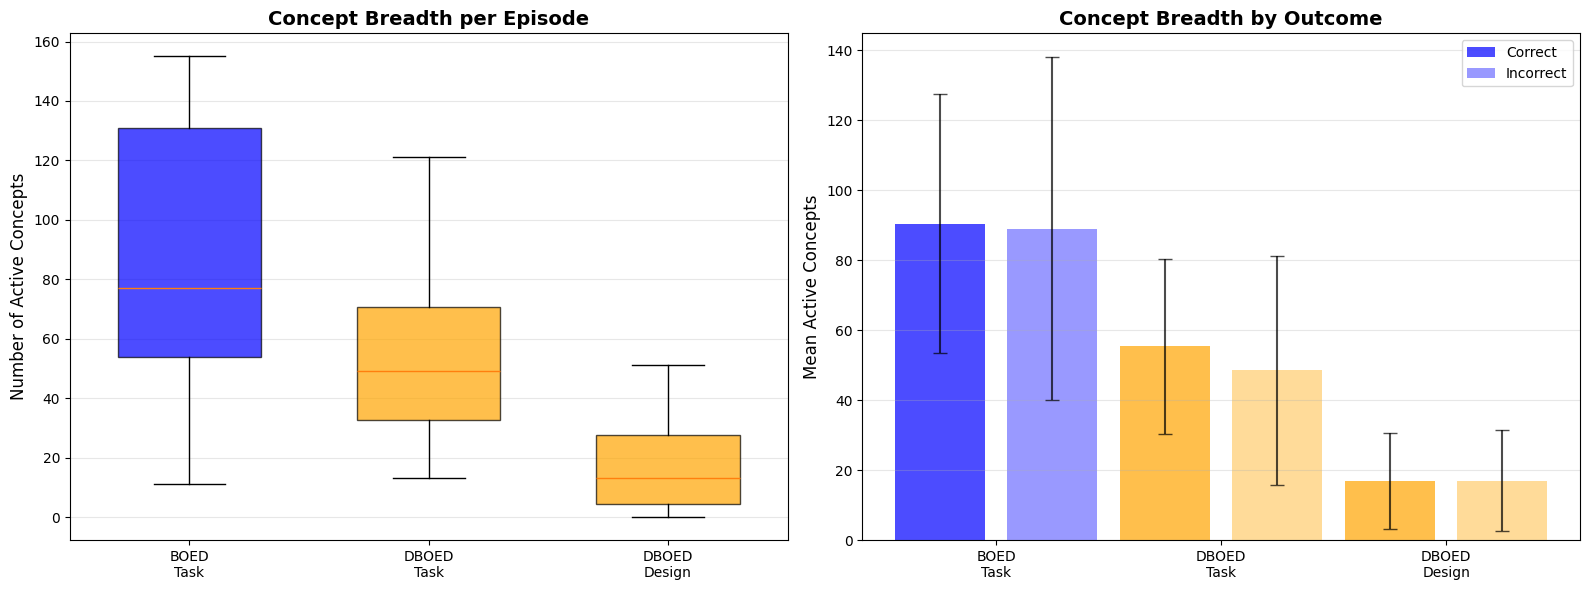

In [195]:
threshold = 0.02

def count_active_concepts_per_episode(df, threshold=0.03):
    def process_group(group):
        signals = np.vstack(group['concept_signal_normalized'].values)
        
        max_salience = signals.max(axis=0)
        
        n_active = (max_salience > threshold).sum()
        
        return pd.Series({
            'n_active_concepts': n_active,
            'episode_accuracy': group.iloc[0]['episode_accuracy'],
            'n_steps': len(group)
        })
    
    return df.groupby(['episode_id', 'folder', 'belief_type']).apply(process_group).reset_index()

concept_breadth = count_active_concepts_per_episode(df, threshold=threshold)

print(f"\nConcept Breadth Analysis (threshold = {threshold})")
print("="*80)
summary_data = []
for folder, belief_type, label in belief_combos:
    subset = concept_breadth[(concept_breadth['folder'] == folder) & 
                             (concept_breadth['belief_type'] == belief_type)]['n_active_concepts']
    summary_data.append({
        'Belief Type': label,
        'Mean ± SD': f"{subset.mean():.2f} ± {subset.std():.2f}",
        'Median': f"{subset.median():.0f}",
        'Range': f"[{subset.min():.0f}, {subset.max():.0f}]",
        'N Episodes': len(subset)
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Statistical tests
print(f"\n{'='*80}")
print("Statistical Comparisons (t-tests):")
print("="*80)

# Extract data for each group
concept_data = {}
for folder, belief_type, label in belief_combos:
    concept_data[label] = concept_breadth[
        (concept_breadth['folder'] == folder) & 
        (concept_breadth['belief_type'] == belief_type)
    ]['n_active_concepts']

# Pairwise comparisons
comparisons = [
    ('BOED Task', 'DBOED Task'),
    ('DBOED Task', 'DBOED Design'),
    ('BOED Task', 'DBOED Design')
]

comparison_results = []
for group1, group2 in comparisons:
    t_stat, p_val = stats.ttest_ind(concept_data[group1], concept_data[group2])
    diff = concept_data[group1].mean() - concept_data[group2].mean()
    sig = 'YES' if p_val < 0.05 else 'NO'
    comparison_results.append({
        'Comparison': f'{group1} vs {group2}',
        't-statistic': f'{t_stat:.3f}',
        'p-value': f'{p_val:.6f}',
        'Difference': f'{diff:+.2f}',
        'Significant (a=0.05)': sig
    })

comparison_df = pd.DataFrame(comparison_results)
print(comparison_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot
data_to_plot = [
    concept_breadth[(concept_breadth['folder'] == folder) & 
                    (concept_breadth['belief_type'] == belief_type)]['n_active_concepts'].values
    for folder, belief_type, _ in belief_combos
]
labels = [label.replace(' ', '\n') for _, _, label in belief_combos]
bp = axes[0].boxplot(data_to_plot, labels=labels, patch_artist=True, widths=0.6)

colors = [color_map[folder] if folder in color_map else 'purple' for folder, _, _ in belief_combos]
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0].set_ylabel('Number of Active Concepts', fontsize=12)
axes[0].set_title(f'Concept Breadth per Episode', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# By outcome
for i, (folder, belief_type, label) in enumerate(belief_combos):
    color = color_map[folder] if folder in color_map else 'purple'
    subset = concept_breadth[(concept_breadth['folder'] == folder) & 
                            (concept_breadth['belief_type'] == belief_type)]
    
    correct = subset[subset['episode_accuracy'] == 1.0]['n_active_concepts']
    incorrect = subset[subset['episode_accuracy'] == 0.0]['n_active_concepts']
    
    positions = [i*2, i*2 + 1]
    
    axes[1].bar(positions[0], correct.mean(), color=color, alpha=0.7, width=0.8, 
               label=f'{label} Correct' if positions[0] == 0 else '')
    axes[1].bar(positions[1], incorrect.mean(), color=color, alpha=0.4, width=0.8,
               label=f'{label} Incorrect' if positions[0] == 0 else '')
    
    axes[1].errorbar(positions[0], correct.mean(), yerr=correct.std(), 
                    fmt='none', color='black', capsize=5, alpha=0.7)
    axes[1].errorbar(positions[1], incorrect.mean(), yerr=incorrect.std(),
                    fmt='none', color='black', capsize=5, alpha=0.7)

axes[1].set_xticks([i*2 + 0.5 for i in range(len(belief_combos))])
axes[1].set_xticklabels([label.replace(' ', '\n') for _, _, label in belief_combos])
axes[1].set_ylabel('Mean Active Concepts', fontsize=12)
axes[1].set_title('Concept Breadth by Outcome', fontsize=14, fontweight='bold')
axes[1].legend(['Correct', 'Incorrect'], loc='upper right')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

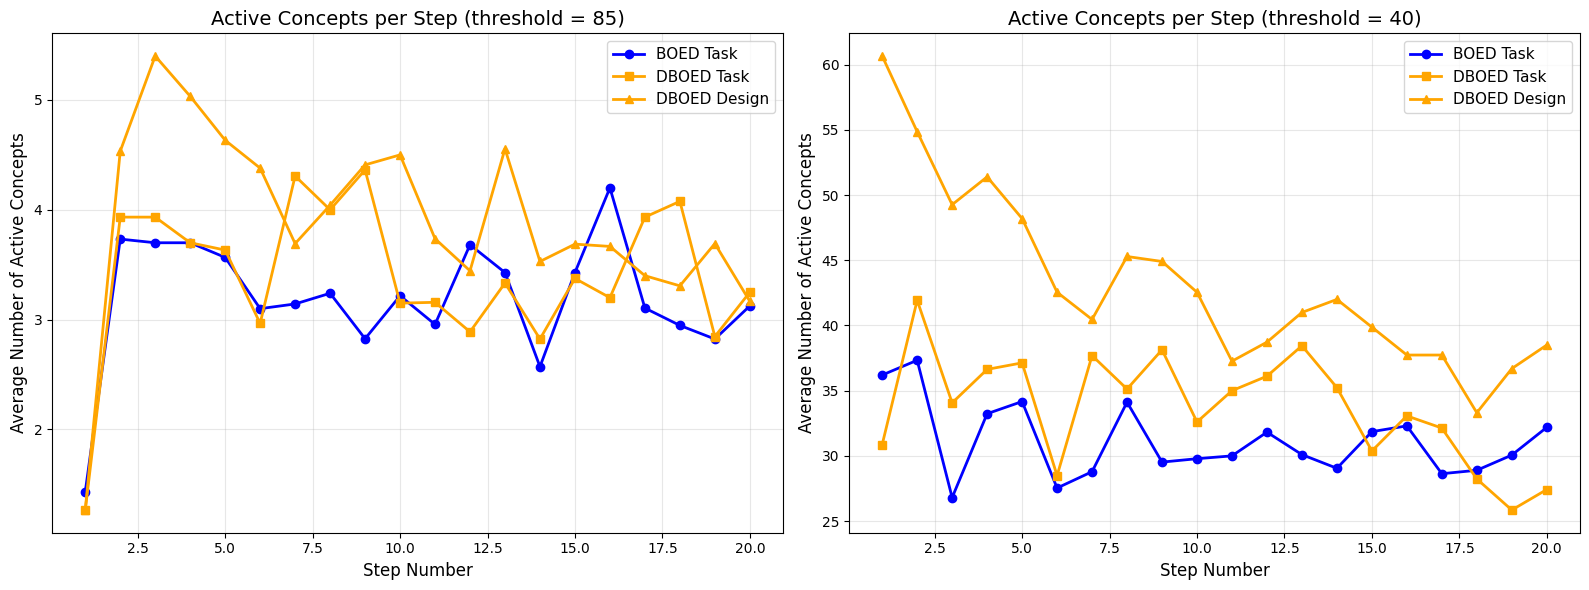

In [196]:
def count_active_at_step(df, threshold):
    results = []
    
    for (folder, belief_type, step_number), group in df.groupby(['folder', 'belief_type', 'step_number']):
        signals = np.vstack(group['concept_signal'].values)
        
        active_per_episode = (signals > threshold).sum(axis=1)
        avg_active = active_per_episode.mean()
        
        results.append({
            'folder': folder,
            'belief_type': belief_type,
            'step_number': step_number,
            'avg_active_concepts': avg_active
        })
    
    return pd.DataFrame(results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

threshold_high = 85
threshold_low = 40

markers = ['o', 's', '^']

for ax, threshold in [(ax1, threshold_high), (ax2, threshold_low)]:
    active_by_step = count_active_at_step(df, threshold)
    
    for (folder, belief_type, label), marker in zip(belief_combos, markers):
        data = active_by_step[(active_by_step['folder'] == folder) & 
                              (active_by_step['belief_type'] == belief_type)]
        ax.plot(data['step_number'], data['avg_active_concepts'], 
                label=label, color=color_map[folder], linewidth=2, marker=marker)
    
    ax.set_xlabel('Step Number', fontsize=12)
    ax.set_ylabel('Average Number of Active Concepts', fontsize=12)
    ax.set_title(f'Active Concepts per Step (threshold = {threshold})', fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [197]:
def total_concept_embedding_change_per_episode(df, normalize=False):
    df = df.sort_values(["episode_id", "folder", "belief_type", "step_number"])
    
    episode_totals = (
        df.groupby(["episode_id", "folder", "belief_type"], group_keys=False)
          .apply(
              lambda g: pd.Series({
                  "total_change": np.sum([
                      np.linalg.norm(g.iloc[i+1]["concept_signal"] - g.iloc[i]["concept_signal"])
                      for i in range(len(g) - 1)
                  ]) if len(g) > 1 else 0,
                  "num_steps": len(g),
                  "accuracy": g.iloc[0]["episode_accuracy"] if len(g) > 0 else 0
              }),
              include_groups=False
          )
          .reset_index()
    )
    
    episode_totals["outcome"] = episode_totals["accuracy"].apply(
        lambda x: "Correct" if x == 1.0 else "Incorrect"
    )
    
    label_map = {(folder, belief_type): label for folder, belief_type, label in belief_combos}
    episode_totals["belief_label"] = episode_totals.apply(
        lambda row: label_map.get((row["folder"], row["belief_type"]), "Unknown"), axis=1
    )
    
    episode_totals["group"] = episode_totals["belief_label"] + " - " + episode_totals["outcome"]
    
    if normalize:
        episode_totals["total_change"] = episode_totals["total_change"] / episode_totals["num_steps"]

        return episode_totals

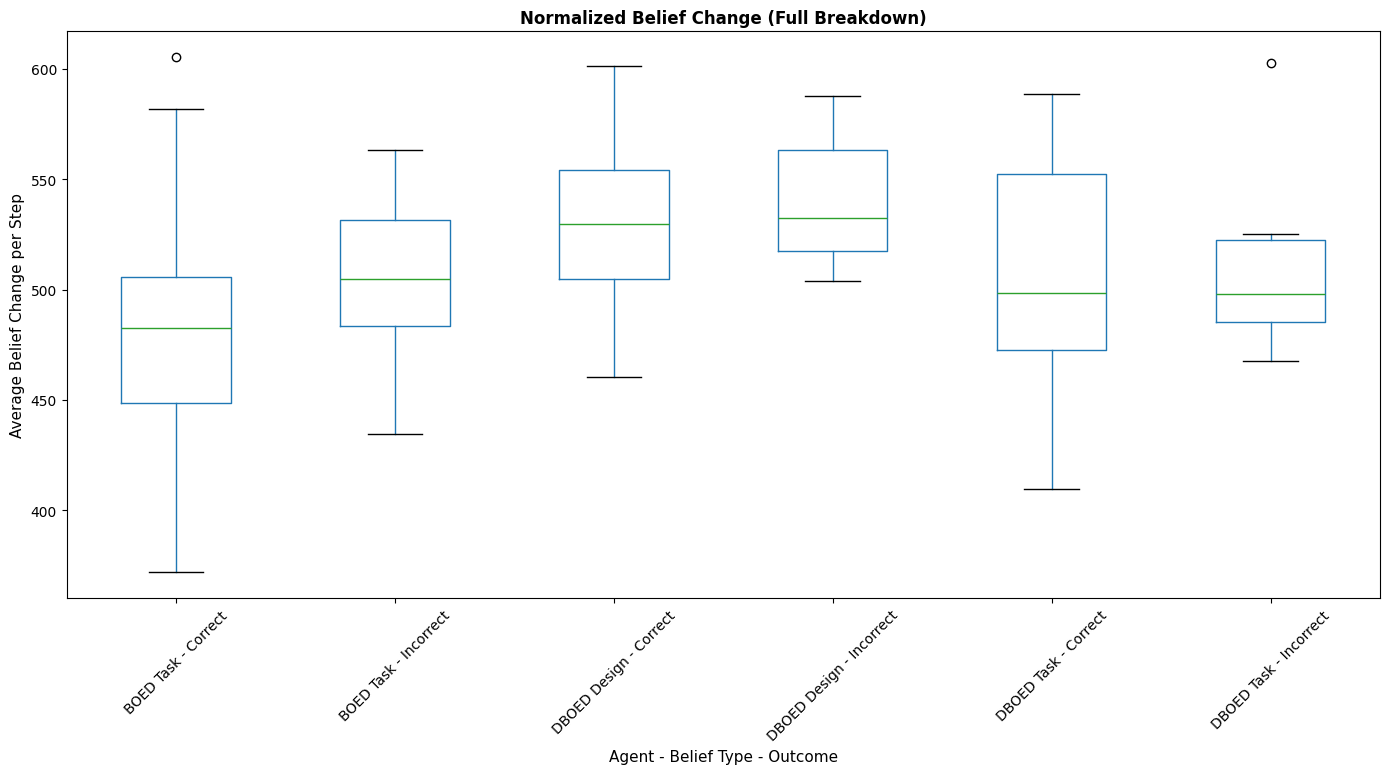

In [198]:
fig, ax = plt.subplots(1, 1, figsize=(14, 8))

df_normalized = total_concept_embedding_change_per_episode(df, normalize=True)

df_normalized.boxplot(by="group", column=["total_change"], grid=False, ax=ax, rot=45)
ax.set_title("Normalized Belief Change (Full Breakdown)", fontsize=12, fontweight='bold')
ax.set_ylabel("Average Belief Change per Step", fontsize=11)
ax.set_xlabel("Agent - Belief Type - Outcome", fontsize=11)
ax.get_figure().suptitle("")

plt.tight_layout()
plt.show()

episode: 23-1122


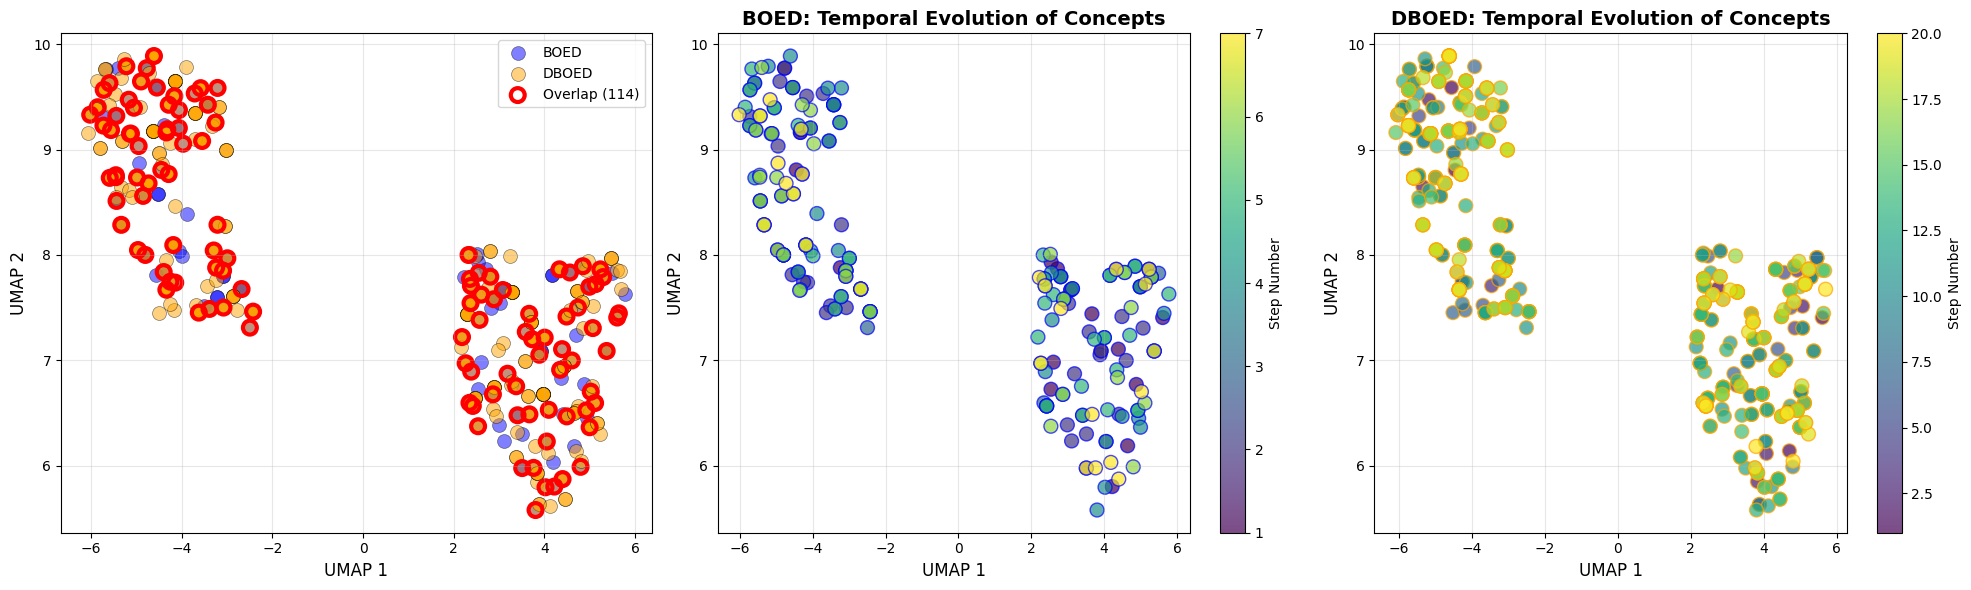

In [202]:
np.random.seed(10)
min_steps = 3
activation_threshold = 50

common_episodes_with_steps = [
    ep for ep in common_episodes 
    if df[(df['episode_id'] == ep) & (df['folder'] == 'boed') & (df['belief_type'] == 'task_beliefs')]['step_number'].nunique() >= min_steps
    and df[(df['episode_id'] == ep) & (df['folder'] == 'dboed') & (df['belief_type'] == 'task_beliefs')]['step_number'].nunique() >= min_steps
]

selected_episode = np.random.choice(common_episodes_with_steps)
print(f"episode: {selected_episode}")

if selected_episode:
    concept_data = []
    for agent, folder in [('BOED', 'boed'), ('DBOED', 'dboed')]:
        agent_data = df[(df['episode_id'] == selected_episode) & 
                       (df['folder'] == folder) & 
                       (df['belief_type'] == 'task_beliefs')].sort_values('step_number')
        
        for _, row in agent_data.iterrows():
            active_concepts = np.where(row['concept_signal'] > activation_threshold)[0]
            for concept_idx in active_concepts:
                concept_data.append({
                    'concept_idx': concept_idx,
                    'concept_name': concepts[concept_idx],
                    'salience': row['concept_signal'][concept_idx],
                    'step': row['step_number'],
                    'agent': agent,
                    'embedding': concept_embeddings[concept_idx]
                })
    
    concept_df = pd.DataFrame(concept_data)
    
    boed_concepts = set(concept_df[concept_df['agent']=='BOED']['concept_idx'].unique())
    dboed_concepts = set(concept_df[concept_df['agent']=='DBOED']['concept_idx'].unique())
    overlap_concepts = boed_concepts & dboed_concepts
    
    unique_concepts = concept_df['concept_idx'].unique()
    unique_embeddings = concept_embeddings[unique_concepts]
    
    if len(unique_concepts) > 2:
        umap_reducer = umap.UMAP(n_components=2, random_state=42, 
                                n_neighbors=min(15, len(unique_concepts)-1), 
                                min_dist=0.1, n_jobs=1)
        concept_umap = umap_reducer.fit_transform(unique_embeddings)
        
        concept_idx_to_umap = {concept_idx: concept_umap[i] for i, concept_idx in enumerate(unique_concepts)}
        concept_df['umap_x'] = concept_df['concept_idx'].map(lambda x: concept_idx_to_umap[x][0])
        concept_df['umap_y'] = concept_df['concept_idx'].map(lambda x: concept_idx_to_umap[x][1])
        
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        
        for agent, color in [('BOED', 'blue'), ('DBOED', 'orange')]:
            agent_data = concept_df[concept_df['agent'] == agent]
            axes[0].scatter(agent_data['umap_x'], agent_data['umap_y'], c=color, alpha=0.5, s=100, label=agent, edgecolors='black', linewidths=0.5)
        
        if overlap_concepts:
            overlap_data = concept_df[concept_df['concept_idx'].isin(overlap_concepts)].drop_duplicates('concept_idx')
            axes[0].scatter(overlap_data['umap_x'], overlap_data['umap_y'],
                             facecolors='none', edgecolors='red', s=100, linewidths=3,
                             label=f'Overlap ({len(overlap_concepts)})', marker='o')
        
        axes[0].set_xlabel('UMAP 1', fontsize=12)
        axes[0].set_ylabel('UMAP 2', fontsize=12)
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        
        for i, (agent, color) in enumerate([('BOED', 'blue'), ('DBOED', 'orange')]):
            agent_data = concept_df[concept_df['agent'] == agent].sort_values('step')
            if len(agent_data) > 0:
                scatter = axes[i + 1].scatter(agent_data['umap_x'], agent_data['umap_y'], 
                                             c=agent_data['step'], cmap='viridis',
                                             s=100, alpha=0.7, edgecolors=color, linewidths=1)
                plt.colorbar(scatter, ax=axes[i + 1], label='Step Number')
                axes[i + 1].set_xlabel('UMAP 1', fontsize=12)
                axes[i + 1].set_ylabel('UMAP 2', fontsize=12)
                axes[i + 1].set_title(f'{agent}: Temporal Evolution of Concepts', 
                                   fontsize=14, fontweight='bold')
                axes[i + 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()